# Modelado con Regresión Lineal
## Análisis Exploratorio, Selección de Características, y Selección de Modelos

**Auitores:** Mario J. Wunderlich, Marco A. Lopez
<br />
**Sección:** V

### Descripción

Este notebook documenta el proceso completo de análisis exploratorio de datos (EDA) para la predicción del precio spot de energía eléctrica en el mercado mayorista de Guatemala (AMM), medido en **Q/MWh**.

Los datos cubren el período **enero 2023 – diciembre 2025** con frecuencia **horaria**, provistos por EEGSA. El objetivo es construir un modelo de regresión lineal que explique la variabilidad del precio spot y permita predicciones futuras.

**Variables objetivo:** `precio` (Q/MWh, horario)

**Estructura del análisis:**
1. Carga y limpieza de datos
2. Ingeniería de características
3. Análisis de correlación (R²)
4. Análisis de series de tiempo (ACF, FFT)
5. Análisis de estacionalidad (horaria, semanal, mensual, anual)
6. Selección final de características

### Librerías Utilizadas

Se utilizan las siguientes librerías principales:
- **pandas / numpy**: manipulación y cálculo numérico
- **seaborn / matplotlib**: visualización
- **requests / yfinance**: obtención de datos externos (temperatura, precipitación, precio de crudo)
- **re**: expresiones regulares para limpieza de datos

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import requests
import yfinance as yf
import os
import json
import re
import datetime as dt

### Métodos para la Carga y Preparación de Datos

Se definen cuatro funciones principales de preparación:

- **`add_sinusoidal_date_column`**: genera encodings cíclicos del día del año usando transformaciones seno/coseno con un *phase shift* de -60 días. Este desfase fue determinado empíricamente: la codificación sinusoidal estándar tiene su pico en el día 91 (equinoccio de primavera), pero el pico de precios en Guatemala ocurre ~60 días después, en mayo-junio, debido al calendario hidrológico de la cuenca del Chixoy.

- **`add_temperature_column`**: obtiene temperatura media diaria y precipitación acumulada desde la API de **Open-Meteo** (gratuita, sin clave), usando las coordenadas de **Cobán, Alta Verapaz** (15.47°N, -90.38°W) como proxy de la cuenca hidrológica del Chixoy, principal generador hidroeléctrico del país. Los datos se cachean en disco para evitar llamadas repetidas.

- **`add_oil_price_column`**: obtiene el precio spot del crudo WTI (contrato `CL=F`) desde Yahoo Finance vía `yfinance`. Los fines de semana y festivos se rellenan con *forward-fill* y *back-fill* dado que los mercados de commodities no operan esos días. Los datos se cachean en CSV.

- **`load_eegsa_price_data`**: función maestra que carga el archivo Excel de EEGSA, estandariza columnas, aplica limpieza opcional, y orquesta todas las funciones de enriquecimiento anteriores.

In [2]:
def add_date_features(data):
    # Extract the day of the week as an integer (Monday=0, Sunday=6)
    data['dia_anual'] = data['dia'].dt.dayofyear
    data['dia_semanal'] = data['dia'].dt.dayofweek
    data['dia_mensual'] = data['dia'].dt.day
    data['mes'] = data['dia'].dt.month
    data['year'] = data['dia'].dt.year
    return data

def add_sinusoidal_date_column(data, phase_shift_days=-60):
    """
    Adds three new columns to the DataFrame based on the 'dia' column:
    'weekday', 'weekday_sin', and 'weekday_cos', where 'weekday' represents
    the day of the week as an integer (0 for Monday, 6 for Sunday), and
    'weekday_sin' and 'weekday_cos' represent cyclical transformations.

    Args:
        data (pd.DataFrame): DataFrame containing a 'dia' column.

    Returns:
        pd.DataFrame: Updated DataFrame with 'weekday', 'weekday_sin', and 'weekday_cos' columns added.
    """
    # Normalize 'weekday' to the range [0, 2π]
    data['dia_anual_norm'] = (2 * np.pi * (phase_shift_days + data['dia_anual'])) / 365
    data['dia_anual_norm'] = data['dia_anual_norm'].astype(float)

    # Create 'weekday_sin' and 'weekday_cos'
    data['dia_anual_sin'] = np.round(np.sin(data['dia_anual_norm'].values), 6)
    data['dia_anual_cos'] = np.round(np.cos(data['dia_anual_norm'].values), 6)

    # Drop the intermediate 'weekday_norm' if not needed
    data.drop(columns=['dia_anual_norm'], inplace=True)

    return data

def add_sinusoidal_hour_column(data):
    data['hora_norm'] = (2 * np.pi * data['hora']) / 24
    data['hora_sin'] = np.round(np.sin(data['hora_norm'].values), 6)
    data['hora_cos'] = np.round(np.cos(data['hora_norm'].values), 6)
    data.drop(columns=['hora_norm'], inplace=True)
    return data

def add_temperature_column(data, lat=15.4696, lon=-90.3767):

    date_min = data['dia'].dt.date.min()
    date_max = data['dia'].dt.date.max()

    # Fetch 1 extra year of history before date_min
    start_date = (date_min - dt.timedelta(days=365 * 2)).isoformat()
    end_date   = date_max.isoformat()

    filename = f'data/temperature_{start_date}_{end_date}.json'
    if os.path.exists(filename):
        result = json.load(open(filename))
    else:
        response = requests.get("https://archive-api.open-meteo.com/v1/archive", params={
            "latitude": lat,
            "longitude": lon,
            "start_date": start_date,
            "end_date": end_date,
            "daily": "temperature_2m_mean,precipitation_sum",
            "timezone": "America/Guatemala"
        })
        result = response.json()
        json.dump(result, open(filename, 'w'))

    dates  = result['daily']['time']
    temps  = result['daily']['temperature_2m_mean']
    precip = result['daily']['precipitation_sum']

    weather_df = pd.DataFrame({
        'dia': pd.to_datetime(dates),
        'temperature': temps,
        'precipitation_mm': precip,
    })

    # Compute lagged precipitation on the full extended date range
    weather_df = weather_df.sort_values('dia').reset_index(drop=True)
    weather_df['precip_lag_1y'] = weather_df['precipitation_mm'].shift(365).rolling(365).sum()

    # Merge only the rows that match the original data's date range
    data = data.merge(weather_df, on='dia', how='left')
    return data

def add_oil_price_column(data):

    # Lag the start date by 1 year
    date_min = data['dia'].dt.date.min()
    date_max = data['dia'].dt.date.max()
    timedelta = dt.timedelta(days=0)

    start_date = (date_min - timedelta).isoformat()
    end_date   = (date_max - timedelta).isoformat()

    filename = f'data/oil_prices_{start_date}_{end_date}.csv'
    if os.path.exists(filename):
        oil = pd.read_csv(filename, index_col=0, parse_dates=True)
    else:
        oil = yf.download("CL=F", start=start_date, end=end_date, auto_adjust=True)
        if isinstance(oil.columns, pd.MultiIndex):
            oil.columns = oil.columns.get_level_values(0)
        oil.to_csv(filename)

    oil = oil[['Close']].rename(columns={'Close': 'oil_price_usd'})
    oil.index.name = 'dia'
    oil.index = pd.to_datetime(oil.index)
    oil = oil.reindex(pd.date_range(date_min, date_max, freq='D')).ffill().bfill()
    oil.index.name = 'dia'
    oil = oil.reset_index()
    # oil = oil.shift(365).dropna()

    data = data.merge(oil, on='dia', how='left')
    return data

def add_price_features(data):
    data['precio_lag_1h'] = data['precio'].shift(1)
    data['precio_lag_24h'] = data['precio'].shift(1 * 24)
    data['precio_lag_168h'] = data['precio'].shift(7 * 24)

    # Agregar columnas de precio con transformación Z
    data['precio_z'] = data.groupby('year')['precio'].transform(lambda x: (x - x.mean()) / x.std())
    data['precio_z_lag_1h'] = data['precio_z'].shift(1)
    data['precio_z_lag_24h'] = data['precio_z'].shift(1 * 24)
    data['precio_z_lag_168h'] = data['precio_z'].shift(7 * 24)
    return data

def load_eegsa_price_data(file_path, clean=False, phase_shift_days=-60):
    """
    Carga datos de precios de energía eléctrica desde un archivo Excel, estandariza las columnas,
    elimina las primeras filas innecesarias y convierte la columna de fechas al formato datetime.

    Args:
        file_path (str): Ruta al archivo Excel que contiene los datos.

    Returns:
        pd.DataFrame: DataFrame con las columnas 'dia', 'hora' y 'precio', donde 'dia' es de tipo datetime.
    """
    data = pd.read_excel(file_path)

    # Estandarizar nombres de las columnas
    data = data.iloc[3:]
    data.columns = ['dia', 'hora', 'precio']

    if clean:
        data['precio'] = (
           data['precio'].astype(str)
            .str.strip()                                    # remove whitespace
            .str.replace(r'[^\d.]', '', regex=True)         # remove non-numeric chars
            .apply(lambda x: pd.to_numeric(x, errors='coerce'))
        )

    # Convertir fechas
    data['dia'] = pd.to_datetime(data['dia'], format='%d/%m/%Y')

    return data

### Métodos para la Limpieza de Datos

Los datos provistos contienen errores introducidos artificialmente que fueron identificados durante el EDA. Se implementaron tres funciones de limpieza algorítmica:

**`clean_hours`**: corrige valores de hora fuera del rango 0–23 (e.g., `220`, `2300`). El error consiste en un dígito extra al final. Se normaliza usando logaritmos para detectar automáticamente el orden de magnitud del error:

$$hora_{corregida} = \frac{hora}{10^{\lfloor \log_{10}(hora) - 1 \rfloor}}$$

**`clean_price_values`**: detecta y corrige precios con caracteres alfanuméricos (e.g., `167.9951l`) o múltiples puntos decimales (e.g., `69.038.0`) usando expresiones regulares. El patrón `[^\d.]` elimina cualquier carácter que no sea dígito o punto decimal.

**`clean_price_outliers`**: detecta precios con errores de magnitud (e.g., `117357` en lugar de `117.357`) usando logaritmos para calcular cuántos órdenes de magnitud separan el outlier de su vecino más cercano:

$$precio_{corregido} = \frac{precio}{10^{\text{round}(\log_{10}(precio / vecino))}}$$

Este método es robusto porque los errores en los datos provistos son siempre potencias exactas de 10.

In [3]:
def clean_hours(data):
    view = data[(data['hora'] > 23) | (data['hora'] < 0)]
    if len(view) == 0:
        print("   *** No hay horas fuera de rango ***")
    for i in range(len(view)):
        hora = view.iloc[i]['hora']
        nueva_hora = int(hora / 10 ** np.floor(np.log10(hora) - 1))
        data.loc[view.iloc[i].name, 'hora'] = nueva_hora
        print('Hora original: ', hora, 'Nueva hora: ', nueva_hora)
    data['hora'] = data['hora'].astype(int)

def clean_price_values(data):
    view = (
        data['precio'].astype(str).str.contains(r'[^\d.]', regex=True) |  # any alpha character
        (data['precio'].astype(str).str.count(r'\.') > 1)                    # more than one decimal point
    )
    view = data[view]
    if len(view) == 0:
        print("   *** No hay precios con formato incorrecto ***")
    for i in range(len(view)):
        precio = view.iloc[i]['precio']
        nuevo_precio = re.sub(r'[^\d.]', '', precio)
        data.loc[view.iloc[i].name, 'precio'] = float(nuevo_precio)
        print('Precio original:', precio, 'Nuevo precio:', nuevo_precio)
    data['precio'] = data['precio'].astype(float)

def clean_price_outliers(data):
    iq01 = data['precio'].quantile(0.01)
    iq99 = data['precio'].quantile(0.99)
    iq = data[data['precio'].between(iq01, iq99)]
    outlier_threshold = iq['precio'].max() + iq['precio'].std() * 3
    view = data[data['precio'] >= outlier_threshold]
    if len(view) == 0:
        print("   *** No hay precios outliers claramente erróneos ***")
    for i in range(len(view)):
        idx = view.iloc[i].name
        precio = view.iloc[i]['precio']
        neighbor = outlier_threshold
        offset = 1
        while neighbor >= outlier_threshold:
            neighbor = data.loc[idx + offset]['precio']
            offset += 1
        magnitude = np.round(np.log10(precio / neighbor))
        nuevo_precio = precio / (10 ** magnitude)
        print('Precio original:', precio, ', - Precio siguiente:', neighbor, ' - Con magnitud: ', magnitude, ' - Nuevo precio:', nuevo_precio)
        data.loc[idx, 'precio'] = nuevo_precio

def clean_data(data, label):
    print(f"\n=== LIMPIAR DATOS PARA AÑO {label} ===")
    print(f"--- Limpiar Horas ---")
    clean_hours(data)

    print(f"--- Limpiar Precios (Formato) ---")
    clean_price_values(data)

    print(f"--- Limpiar Precios (Outliers Erróneos) ---")
    clean_price_outliers(data)

### Cargar y Limpiar la Data

Se cargan y limpian los tres años de datos por separado para facilitar el diagnóstico de errores por año. La limpieza se aplica en orden: **horas → formato de precios → outliers de magnitud**. Este orden es importante porque `clean_price_outliers` requiere que `precio` ya sea numérico.

In [4]:
y2023 = load_eegsa_price_data('data/Precios2023.xls', clean=True, phase_shift_days=-60)
clean_data(y2023, 2023)

y2024 = load_eegsa_price_data('data/Precios2024.xls', clean=True, phase_shift_days=-60)
clean_data(y2024, 2024)

y2025 = load_eegsa_price_data('data/Precios2025.xls', clean=True, phase_shift_days=-60)
clean_data(y2025, 2025)


=== LIMPIAR DATOS PARA AÑO 2023 ===
--- Limpiar Horas ---
Hora original:  220 Nueva hora:  22
Hora original:  230 Nueva hora:  23
Hora original:  2300 Nueva hora:  23
--- Limpiar Precios (Formato) ---
   *** No hay precios con formato incorrecto ***
--- Limpiar Precios (Outliers Erróneos) ---
Precio original: 117357.0 , - Precio siguiente: 146.5635  - Con magnitud:  3.0  - Nuevo precio: 117.357
Precio original: 1376899.0 , - Precio siguiente: 146.5635  - Con magnitud:  4.0  - Nuevo precio: 137.6899
Precio original: 131859.0 , - Precio siguiente: 146.5635  - Con magnitud:  3.0  - Nuevo precio: 131.859
Precio original: 65809.0 , - Precio siguiente: 65.809  - Con magnitud:  3.0  - Nuevo precio: 65.809
Precio original: 144388.0 , - Precio siguiente: 156.9681  - Con magnitud:  3.0  - Nuevo precio: 144.388

=== LIMPIAR DATOS PARA AÑO 2024 ===
--- Limpiar Horas ---
   *** No hay horas fuera de rango ***
--- Limpiar Precios (Formato) ---
   *** No hay precios con formato incorrecto ***
--- Li

### Unificación de Datos

Unificaremos los 3 años de datos proveidos para hacer el análisis con más significancia estadística. La data cubre **26,304 observaciones horarias** (3 años × 365 días × 24 horas), con **43 columnas** incluyendo features derivadas.

In [5]:
data = pd.concat([y2023, y2024, y2025])

# Agregar features de fechas
data = add_date_features(data)

# Agregar features de precio
data = add_price_features(data)

# Agregar features globales
data = add_sinusoidal_hour_column(data)
data = add_sinusoidal_date_column(data, phase_shift_days=-60)

# Agregar features externos
data = add_temperature_column(data, lat=14.6349, lon=-90.5069)
data = add_oil_price_column(data)

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 26304 entries, 0 to 26303
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   dia                26304 non-null  datetime64[us]
 1   hora               26304 non-null  int64         
 2   precio             26300 non-null  float64       
 3   dia_anual          26304 non-null  int32         
 4   dia_semanal        26304 non-null  int32         
 5   dia_mensual        26304 non-null  int32         
 6   mes                26304 non-null  int32         
 7   year               26304 non-null  int32         
 8   precio_lag_1h      26299 non-null  float64       
 9   precio_lag_24h     26276 non-null  float64       
 10  precio_lag_168h    26132 non-null  float64       
 11  precio_z           26300 non-null  float64       
 12  precio_z_lag_1h    26299 non-null  float64       
 13  precio_z_lag_24h   26276 non-null  float64       
 14  precio_z_lag_168h

### Crear Agrupación de Datos por Día

Varios análisis que haremos serán a frecuencia diaria o anual, para encontrar tendencias y patrones estacionales que no son visibles a nivel horario. La temperatura, precipitación y precio se agregan por media diaria.

In [6]:
prices = data.groupby('dia').aggregate({
    'precio': 'mean',
    'temperature': 'first',
    'precipitation_mm': 'first',
    'precip_lag_1y': 'first',
    'oil_price_usd': 'first',
    'dia_anual': 'mean',
    'dia_anual_sin': 'mean',
    'dia_anual_cos': 'mean'
})

prices.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1096 entries, 2023-01-01 to 2025-12-31
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   precio            1096 non-null   float64
 1   temperature       1096 non-null   float64
 2   precipitation_mm  1096 non-null   float64
 3   precip_lag_1y     1096 non-null   float64
 4   oil_price_usd     1096 non-null   float64
 5   dia_anual         1096 non-null   float64
 6   dia_anual_sin     1096 non-null   float64
 7   dia_anual_cos     1096 non-null   float64
dtypes: float64(8)
memory usage: 77.1 KB


### Análisis de Correlación a Gran Escala

Comprobaremos las correlaciones entre las variables externas y el precio usando **R²**, que representa la proporción de varianza en Y explicada linealmente por X. A diferencia de Pearson, R² es siempre positivo y más intuitivo para comparar poder predictivo.

**Hallazgos principales:**
- `temperature` → `precio`: **R² = 0.44** — variable externa más predictiva. La temperatura actúa como proxy de disponibilidad hídrica: épocas cálidas y secas reducen la generación hidroeléctrica y elevan el precio spot.
- `dia_anual_cos` (con phase shift -60d) → `precio`: **R² = 0.44** — el encoding sinusoidal correctamente desfasado captura la estacionalidad anual con igual fuerza.
- `oil_price_usd` → `precio`: **R² = 0.05** — correlación débil esperada dado que Guatemala opera una matriz predominantemente hidroeléctrica.
- `precipitation_mm` → `precio`: **R² ≈ 0.00** — sin correlación directa. Sin embargo, con lags de 1–2 años (`precip_lag_2y`) el R² sube a 0.07–0.11, sugiriendo que el efecto opera a través de ciclos hidrológicos multi-anuales posiblemente relacionados con ENSO.

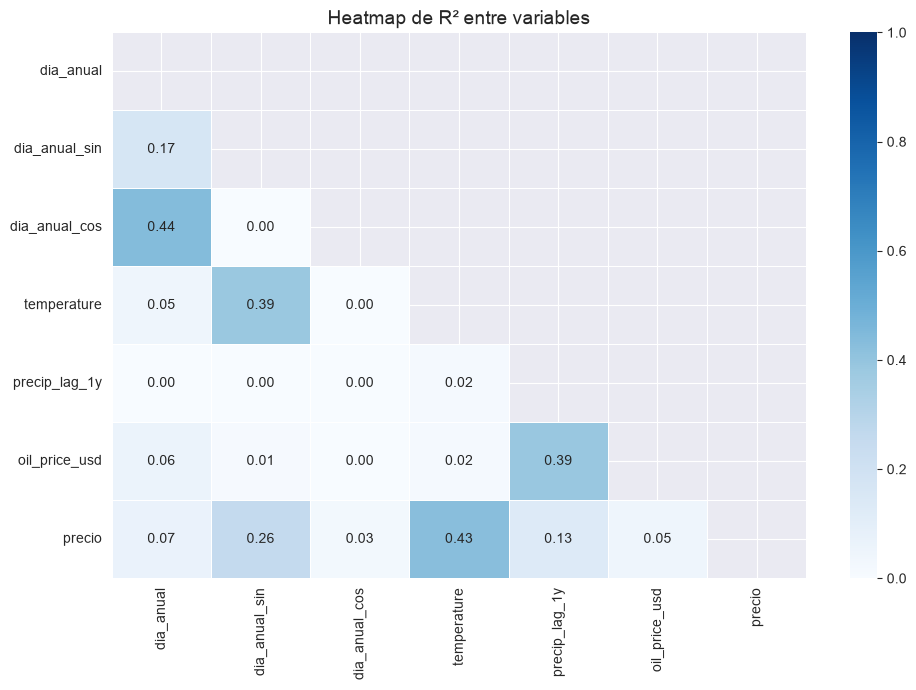

In [7]:
def plot_correlation_heatmap(data, features):
    """
    Plots a heatmap of R² values between every pair of features.
    R² is computed as the square of the Pearson correlation coefficient.
    """
    # Compute Pearson correlation matrix then square it for R²
    corr = data[features].corr()
    r2 = corr ** 2

    mask = np.triu(np.ones_like(r2, dtype=bool))  # upper triangle mask

    fig, ax = plt.subplots(figsize=(10, 7))
    sns.heatmap(
        r2,
        mask=mask,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        vmin=0, vmax=1,
        linewidths=0.5,
        ax=ax
    )
    ax.set_title('Heatmap de R² entre variables', fontsize=14)
    plt.tight_layout()
    plt.show()

features_to_plot = ['dia_anual', 'dia_anual_sin', 'dia_anual_cos', 'temperature', 'precip_lag_1y', 'oil_price_usd', 'precio']
plot_correlation_heatmap(prices, features_to_plot)

### Análisis de Temperatura vs. Precio

La temperatura media diaria muestra correlación visual clara con el precio spot (R²=0.44). Los picos de temperatura en marzo-junio coinciden con los picos de precio, confirmando el mecanismo hidrológico: la época seca reduce la generación hidroeléctrica y fuerza el despacho de plantas térmicas a mayor costo marginal.

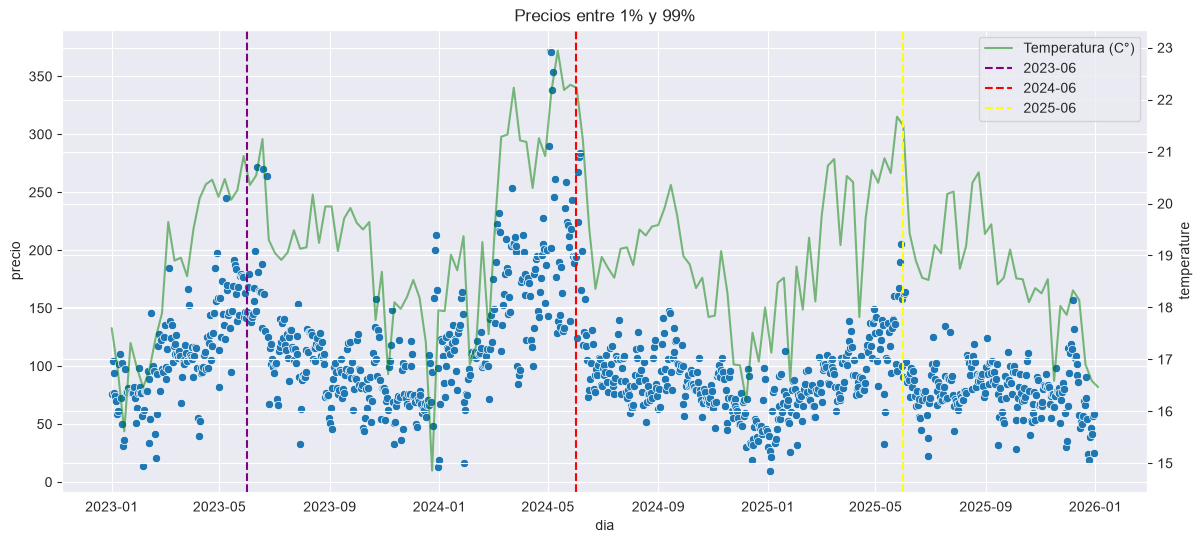

In [8]:
fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

sns.scatterplot(data=prices, x='dia', y='precio', ax=ax1)

temp = prices['temperature'].resample('W').mean().reset_index()
sns.lineplot(data=temp, x='dia', y='temperature', color='green', linestyle='-', alpha=0.5, label='Temperatura (C°)', ax=ax2)

plt.xticks(rotation=45, ha='right')
plt.title('Precios entre 1% y 99%')
plt.axvline(x=dt.datetime(day=1, month=6, year=2023), color='purple', linestyle='--', label='2023-06')
plt.axvline(x=dt.datetime(day=1, month=6, year=2024), color='red', linestyle='--', label='2024-06')
plt.axvline(x=dt.datetime(day=1, month=6, year=2025), color='yellow', linestyle='--', label='2025-06')
plt.legend()
plt.show()

### Análisis de Precipitación vs. Precio

A diferencia de la temperatura, la precipitación diaria no muestra correlación directa con el precio. Al aplicar lags de 1–2 años se detecta señal débil (R²=0.03–0.11), sugiriendo que el estado de los reservorios responde a la acumulación de lluvia en ciclos multi-anuales. Adicionalmente, las coordenadas de Guatemala Ciudad no representan adecuadamente la cuenca del Chixoy, el principal embalse del sistema.

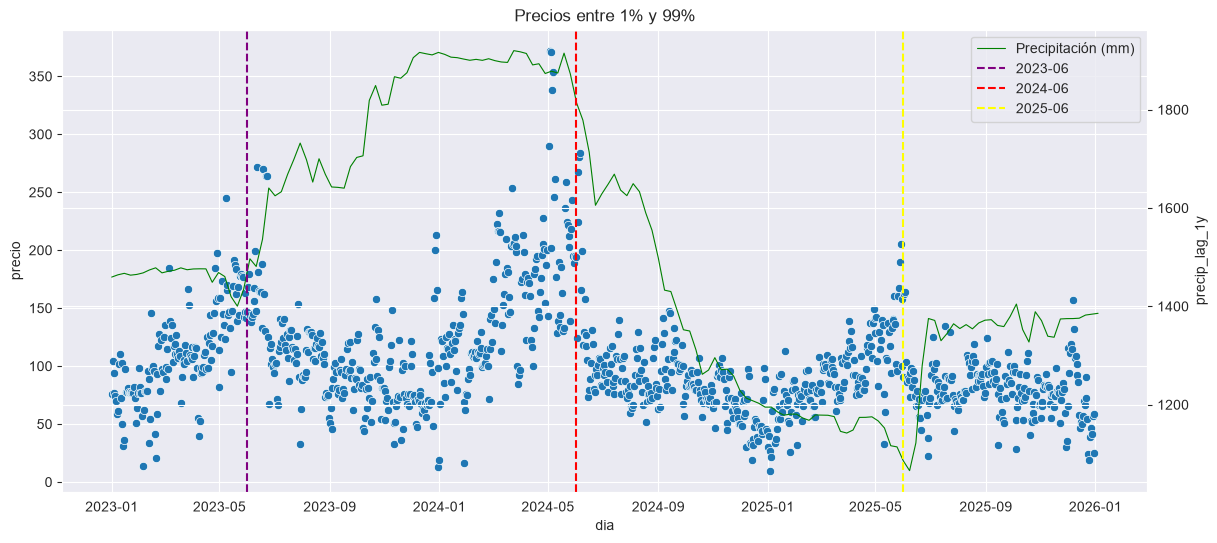

In [9]:
fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

sns.scatterplot(data=prices, x='dia', y='precio', ax=ax1)

precip = prices.resample('W').mean()
sns.lineplot(data=precip, x='dia', y='precip_lag_1y', color='green', linestyle='-', linewidth=0.8, label='Precipitación (mm)', ax=ax2)

# ax2.set_ylim(bottom=-10, top=precip['precipitation_mm'].max() * 1.2)

plt.xticks(rotation=45, ha='right')
plt.title('Precios entre 1% y 99%')
plt.axvline(x=dt.datetime(day=1, month=6, year=2023), color='purple', linestyle='--', label='2023-06')
plt.axvline(x=dt.datetime(day=1, month=6, year=2024), color='red', linestyle='--', label='2024-06')
plt.axvline(x=dt.datetime(day=1, month=6, year=2025), color='yellow', linestyle='--', label='2025-06')
plt.legend()
plt.show()

### Verificación de Temporalidad Sinusoidal

Con *phase shift* = -60 días, el seno se alinea visualmente con los picos anuales de precio. El desfase fue determinado empíricamente: `sin(2π·día/365)` tiene su máximo en el día 91, pero el pico de precios ocurre en el día ~150 (finales de mayo). Al aplicar el desfase, `dia_anual_sin` mejora de R²=0.17 a R²=0.27 contra `precio`.

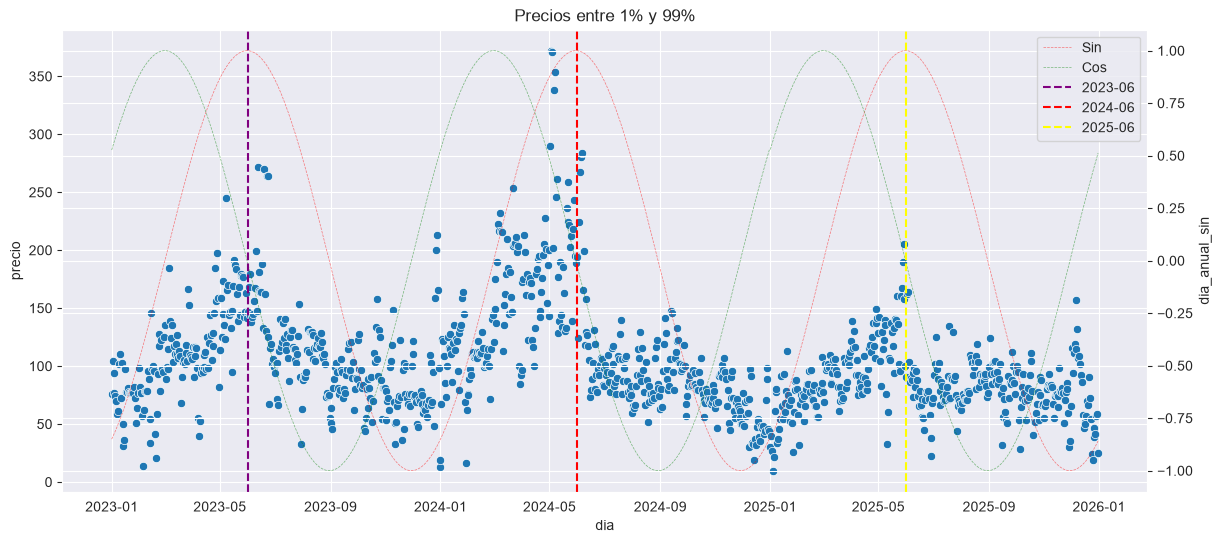

In [10]:
fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

sns.scatterplot(data=prices, x='dia', y='precio', ax=ax1)
sns.lineplot(data=prices, x='dia', y='dia_anual_sin', color='red', linestyle='--', linewidth=0.5, alpha=0.5, label='Sin', ax=ax2)
sns.lineplot(data=prices, x='dia', y='dia_anual_cos', color='green', linestyle='--', linewidth=0.5, alpha=0.5, label='Cos', ax=ax2)
plt.xticks(rotation=45, ha='right')
plt.title('Precios entre 1% y 99%')
plt.axvline(x=dt.datetime(day=1, month=6, year=2023), color='purple', linestyle='--', label='2023-06')
plt.axvline(x=dt.datetime(day=1, month=6, year=2024), color='red', linestyle='--', label='2024-06')
plt.axvline(x=dt.datetime(day=1, month=6, year=2025), color='yellow', linestyle='--', label='2025-06')
plt.legend()
plt.show()

### Fast Fourier Transforms: Espectro de Poder

Para verificar objetivamente qué periodicidades dominan la serie, calculamos el espectro de potencia FFT sobre los precios diarios promedio.

**Hallazgos:**
- **Ciclo anual (365 días)**: pico dominante (~3.2×10⁸), confirma que la estacionalidad anual es la estructura principal.
- **Ciclo semestral (180 días)**: pico secundario visible (~0.4×10⁸), correspondiente al armónico de medio año — precios altos en mayo-junio con una estructura secundaria en diciembre-enero.
- **Ciclos semanales y mensuales**: planos en comparación. El ciclo semanal es real pero opera a escala horaria, no diaria.

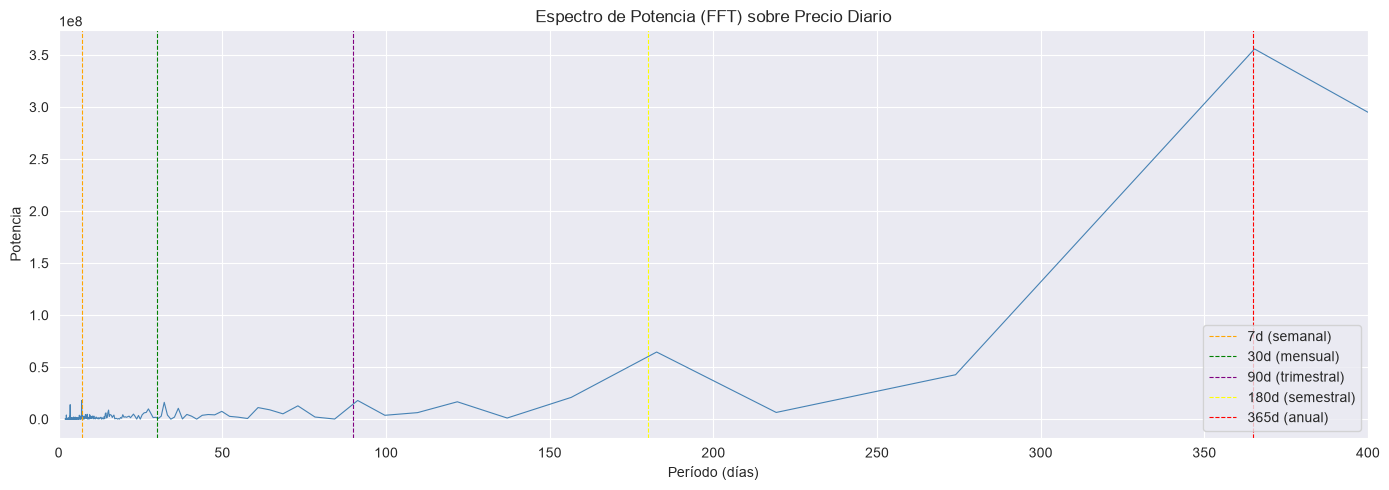

In [11]:
# Use daily averages for cleaner signal
daily_avg = prices['precio']
N = len(daily_avg)
fft_vals  = np.fft.rfft(daily_avg.values)
fft_power = np.abs(fft_vals) ** 2
frequencies = np.fft.rfftfreq(N, d=1)

# Keep index 1 onward on both arrays to skip DC component
frequencies = frequencies[1:]
fft_power   = fft_power[1:]

# Convert to periods — both arrays are now the same length
periods = 1 / frequencies
power   = fft_power

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(periods, power, linewidth=0.8, color='steelblue')
ax.set_xlabel('Período (días)')
ax.set_ylabel('Potencia')
ax.set_title('Espectro de Potencia (FFT) sobre Precio Diario')

for period, label, color in [
    (7,   '7d (semanal)', 'orange'),
    (30,  '30d (mensual)', 'green'),
    (90,  '90d (trimestral)', 'purple'),
    (180,  '180d (semestral)', 'yellow'),
    (365, '365d (anual)', 'red')
]:
    ax.axvline(x=period, color=color, linestyle='--', linewidth=0.8, label=label)

ax.set_xlim(0, 400)
ax.legend()
plt.tight_layout()
plt.show()

### Análisis ACF

Análisis de autocorrelación a frecuencia semanal (104 lags = 2 años) para confirmar la estructura temporal de la serie.

**Interpretación:**
- **Eje X**: lag en semanas — correlación del precio con su valor N semanas atrás
- **Eje Y**: coeficiente de autocorrelación (-1 a 1)
- **Banda de confianza**: ±1.96/√N al 95%. Se ensancha a lags altos por menor cantidad de datos disponibles. Puntos fuera de la banda son estadísticamente significativos.

**Hallazgos:**
- Lags 1–10: correlación positiva alta (0.8→0.2) — fuerte memoria de corto plazo
- Lag ~26 semanas: correlación negativa (~-0.25) — hace 6 meses era época opuesta del año
- Lag ~52 semanas: correlación positiva (~0.27) — confirmación de estacionalidad anual
- La forma sinusoidal del ACF es la firma característica de una serie con estacionalidad anual pronunciada

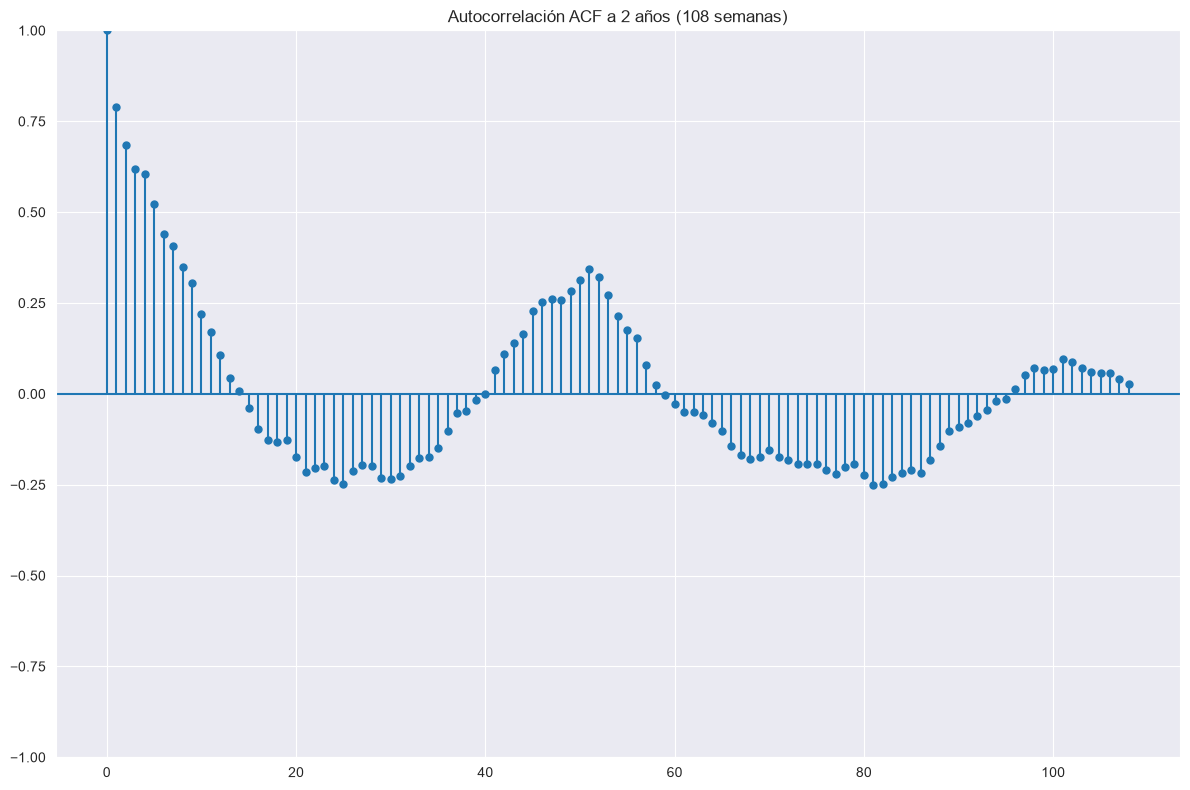

In [12]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax1 = plt.subplots(figsize=(12, 8))

y = prices['precio'].resample('W').mean()

years = 2
plot_acf(y, lags=54*years, ax=ax1, alpha=None)
ax1.set_title(f'Autocorrelación ACF a {years} años ({years*54} semanas)')

plt.tight_layout()
plt.show()

### Análisis de Estacionalidad a Menor Escala

Análisis de la estacionalidad en escala horaria y semanal mediante el perfil típico de 168 horas (7 días × 24 horas).

**Patrón 1 — Ciclo diario asimétrico**: valle entre las 0–5h (~65–78 Q/MWh), rampa gradual desde las 6h, pico sostenido entre las 10–22h (~115–132 Q/MWh), caída abrupta después de las 22h. Esta asimetría no puede ser capturada por encodings sinusoidales; se requieren **dummies de hora** (23 variables binarias, con hora 0 como referencia) para que el modelo aprenda libremente el precio de cada hora.

**Patrón 2 — Descuento de fin de semana**: sábado y domingo presentan precios ~15–20% menores con un perfil más plano, capturado con dummies de día de semana.

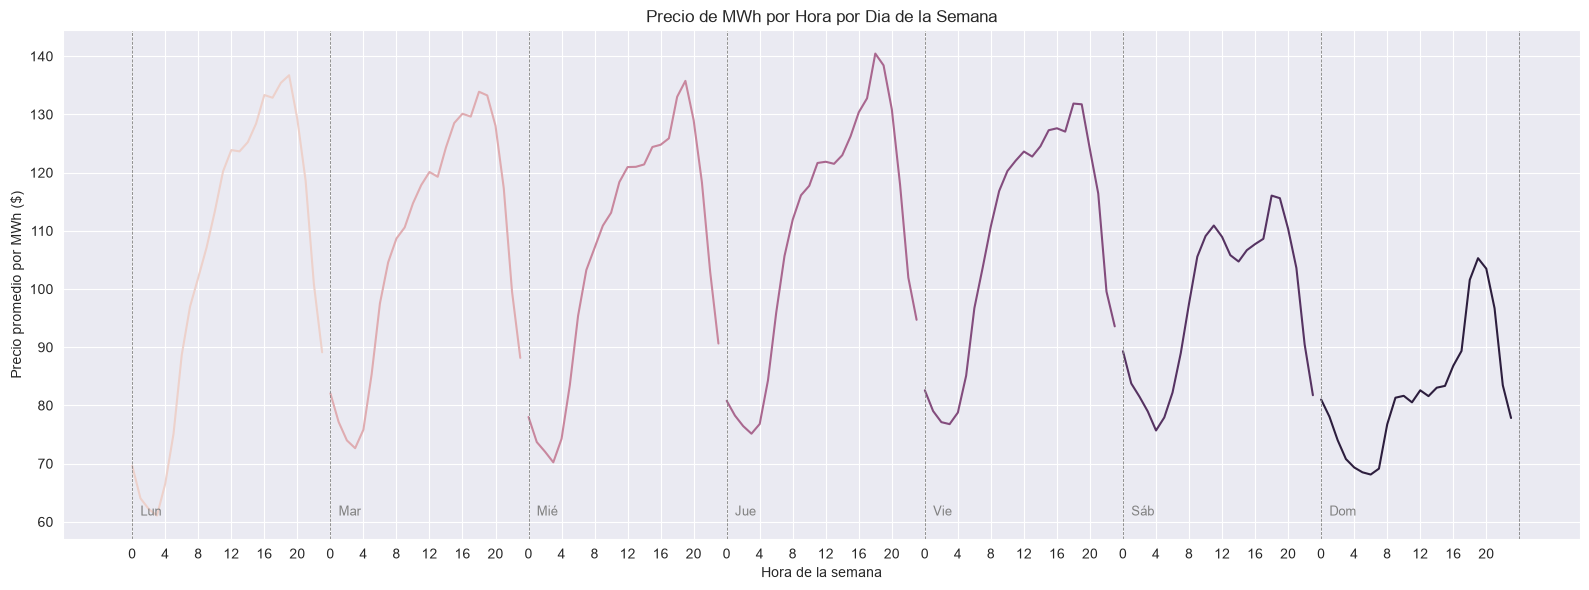

In [13]:
hourly_profile = (
    data
    .groupby(['dia_semanal', 'hora'])['precio']
    .mean()
    .reset_index()
)

hourly_profile = hourly_profile.sort_values(['dia_semanal', 'hora']).reset_index(drop=True)
hourly_profile = hourly_profile.copy()
hourly_profile = hourly_profile[~ (hourly_profile['hora'] > 23)]

fig, ax = plt.subplots(figsize=(16, 6))
sns.lineplot(hourly_profile, x=np.arange(len(hourly_profile)), y='precio', hue='dia_semanal')

day_names = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom', '']
for d in range(8):
    ax.axvline(x=d * 24, color='gray', linestyle='--', linewidth=0.6)
    ax.text(d * 24 + 1, hourly_profile['precio'].min(), day_names[d], fontsize=9, color='gray')

ax.set_xlabel('Hora de la semana')
ax.set_ylabel('Precio promedio por MWh ($)')
ax.set_title('Precio de MWh por Hora por Dia de la Semana')

ticks = range(0, len(hourly_profile), 4)
ax.set_xticks(ticks)
ax.set_xticklabels([str(hourly_profile['hora'].iloc[i] % 24) for i in ticks])
ax.legend().remove()

plt.tight_layout()
plt.show()

### Análisis a Media Escala

Análisis mensual para determinar si existen patrones intra-mensuales independientes de la estacionalidad anual ya capturada.

**Hallazgo clave**: al visualizar precios en cambio porcentual (Δ%), las tres líneas anuales (2023, 2024, 2025) se superponen casi perfectamente en todos los meses. Esto confirma que **no existe un patrón intra-mensual independiente** — la variabilidad mensual es enteramente explicada por el nivel anual (encoding sinusoidal) y el nivel inter-anual (dummies de año). Los meses como feature adicional serían redundantes.

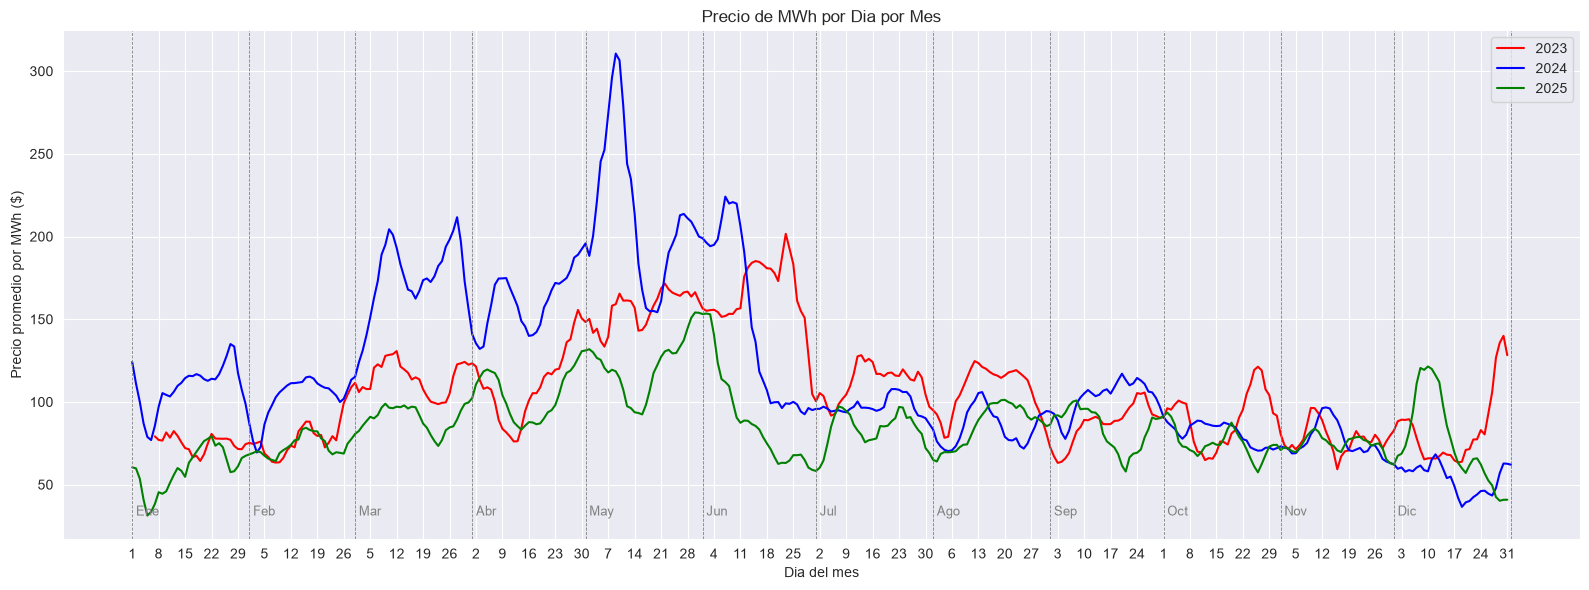

In [14]:
daily = data.copy()
daily['year'] = daily['dia'].dt.year
daily['mes'] = daily['dia'].dt.month
daily['dia_del_mes'] = daily['dia'].dt.day
# iq01 = daily['precio'].quantile(0.01)
# iq99 = daily['precio'].quantile(0.99)
# daily = daily[daily['precio'].between(iq01, iq99)]
daily_profile = (
    daily
    .groupby(['year', 'mes', 'dia_del_mes'])['precio'].mean()
    .reset_index()
)

daily_profile['precio'] = daily_profile['precio'].rolling(7).mean()

daily_profile = daily_profile.sort_values(['year', 'mes', 'dia_del_mes']).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(16, 6))
colors = ['red', 'blue', 'green']
for year_index in range(3):
    year = 2023 + year_index
    y = daily_profile[daily_profile['year'] == year]
    sns.lineplot(y, x=np.arange(len(y)), color=colors[year_index], y='precio', ax=ax, label=year)

month_names = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic', '']
month_lengths = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
offsets = [0] + list(np.cumsum(month_lengths))

for m in range(13):
    ax.axvline(x=offsets[m], color='gray', linestyle='--', linewidth=0.6)
    ax.text(offsets[m] + 1, daily_profile['precio'].min(), month_names[m], fontsize=9, color='gray')

ax.set_xlabel('Dia del mes')
ax.set_ylabel('Precio promedio por MWh ($)')
ax.set_title('Precio de MWh por Dia por Mes')

ticks = range(0, 365, 7)
ax.set_xticks(list(ticks))
ax.set_xticklabels([str(daily_profile['dia_del_mes'].iloc[i]) for i in ticks])
ax.legend()

plt.tight_layout()
plt.show()

In [15]:
def render_monthly_profile(data, rolling_window=7, use_pct_change=False):
    monthly = data.copy().reset_index()
    monthly['dia_del_mes'] = monthly['dia'].dt.day
    monthly['mes'] = monthly['dia'].dt.month
    monthly['year'] = monthly['dia'].dt.year

    line_style = '-'
    label = 'Precio'

    if use_pct_change:
        monthly['precio'] = monthly['precio'].rolling(rolling_window).mean().pct_change()
        line_style = '--'
        label = 'Precio Δ%'
    else:
        monthly['precio'] = monthly['precio'].rolling(rolling_window).mean()

    y = monthly.groupby(['year', 'mes', 'dia_del_mes'])['precio'].mean().reset_index()
    y['precio'].apply(lambda x: round(x, 2))

    fig, axes = plt.subplots(6, 2, figsize=(16, 16))
    meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
    mes_orden = [0, 2, 4, 6, 8, 10, 1, 3, 5, 7, 9, 11]
    colors = ['red', 'blue', 'green']
    for mes_index in range(12):
        mes = mes_orden[mes_index]

        ax = axes[mes_index % 6, mes_index // 6]
        ax.set_ylabel(label)
        for year_index in range(0, 3):
            m = y[(y['year'] == year_index + 2023) & (y['mes'] == mes + 1)]
            sns.lineplot(m, x='dia_del_mes', y='precio', ax=ax, linestyle=line_style, color=colors[year_index], label=year_index + 2023)

        ax.set_title(meses[mes])
        next_month = mes + 2
        next_year = 2023
        if next_month > 12:
            next_month -= 12
            next_year += 1
        last_day = (dt.datetime(next_year, next_month, 1) - dt.timedelta(days=1)).day
        ax.set_xticks(ticks=range(1, last_day, 3))
        ax.tick_params(axis='x', rotation=45)
        ax.set_xlabel(f'Dia del Mes ({meses[mes]})')
        ax.legend(loc='upper right')
    plt.tight_layout()

### Visualización Mensual (cambios porcentuales)

Al normalizar por cambio porcentual, los tres años colapsan a un patrón idéntico en todos los meses, confirmando que la dinámica intra-mensual es estable inter-anualmente. No se requieren features mensuales específicos.

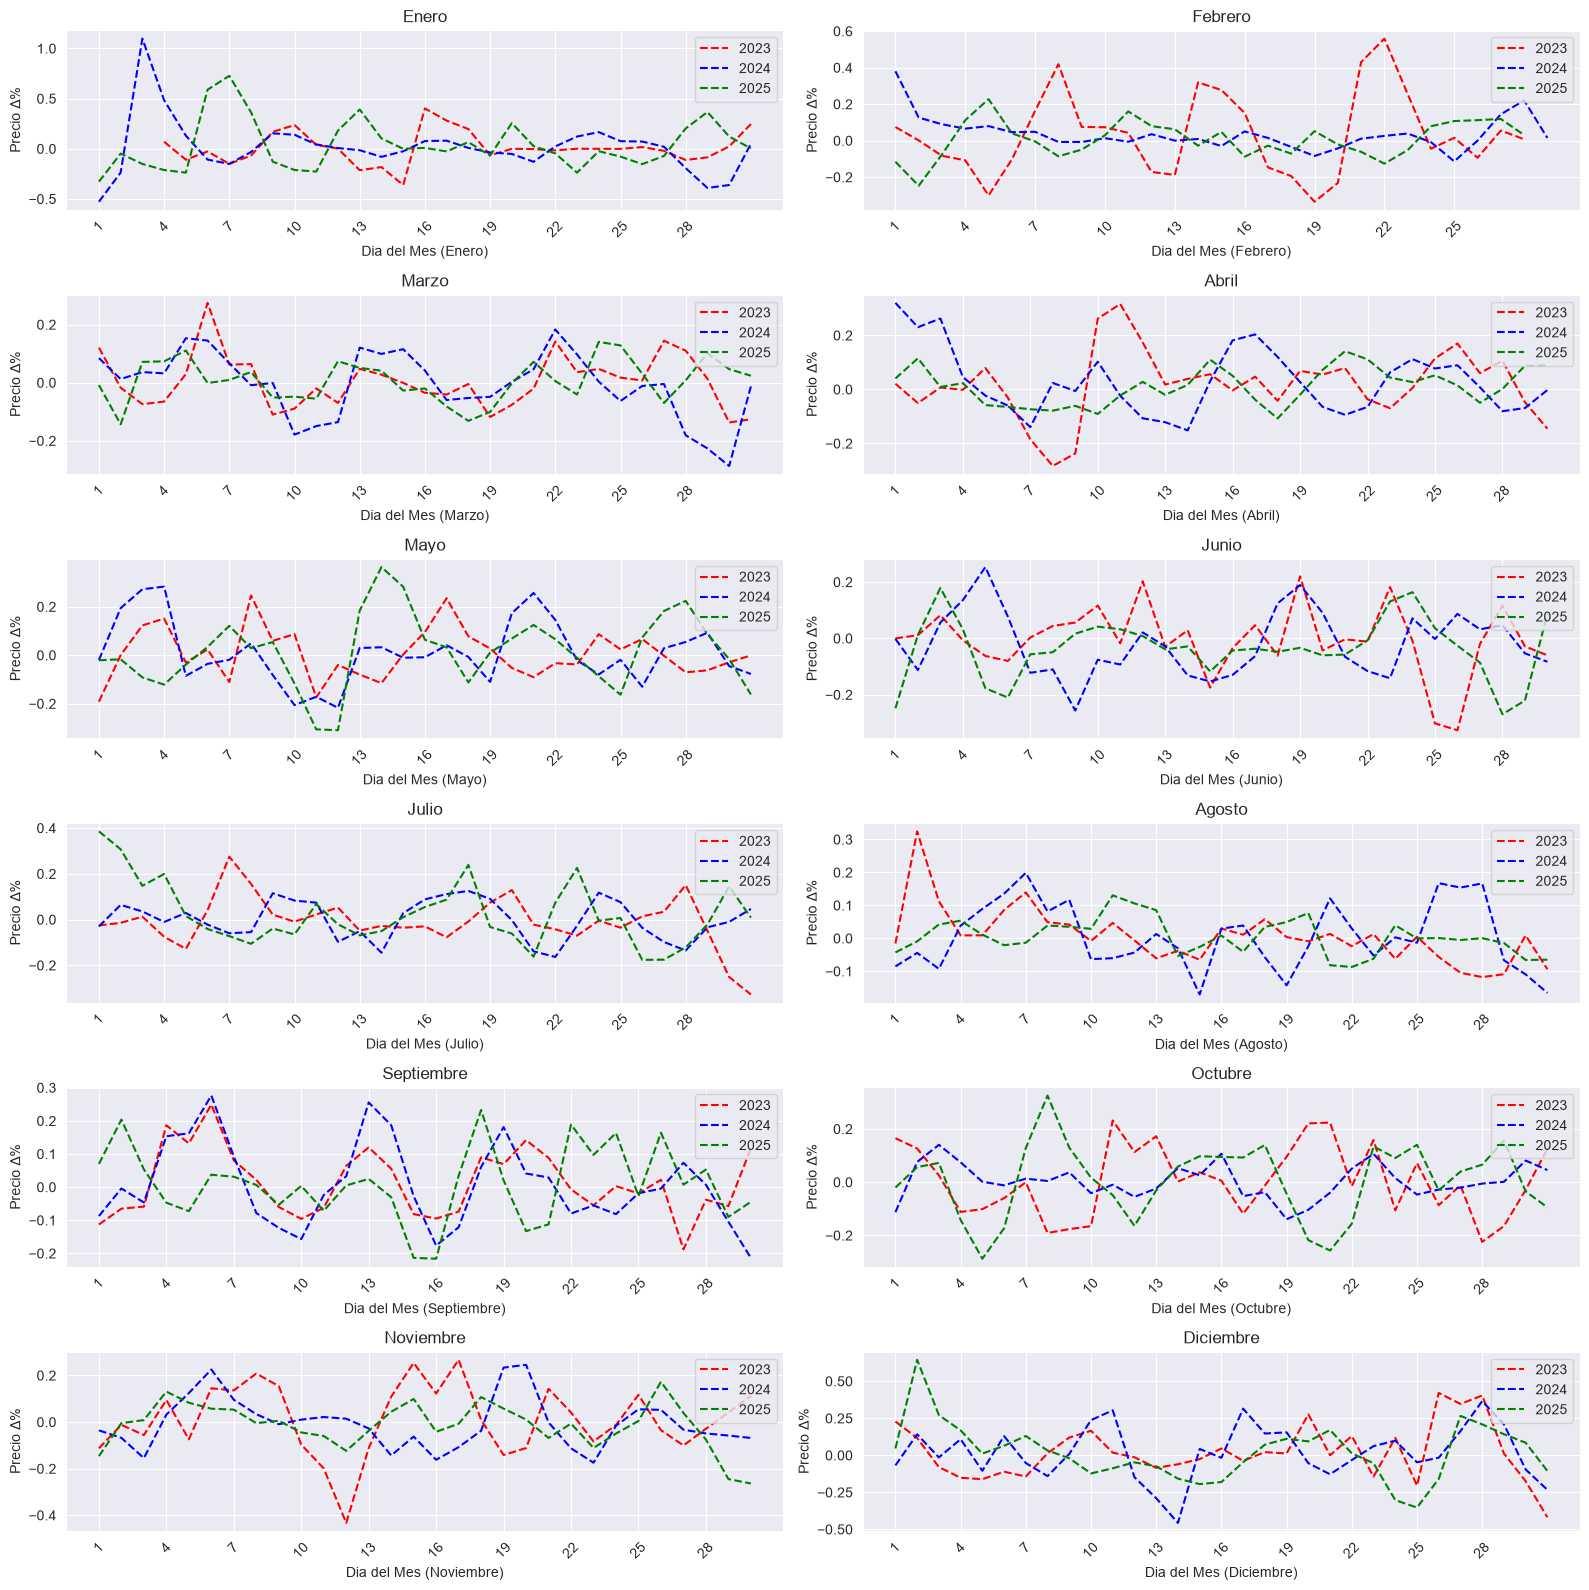

In [16]:
render_monthly_profile(prices, rolling_window=3, use_pct_change=True)

### Visualización Mensual (precios absolutos)

En precios absolutos se observa la jerarquía inter-anual: **2024 consistentemente más caro** (especialmente Q1-Q2), seguido de 2023 y 2025 como el año más barato. Este diferencial posiblemente refleja el ciclo ENSO: 2024 fue un año de El Niño fuerte, que retrasa el inicio de lluvias en Guatemala y eleva los precios spot en época seca.

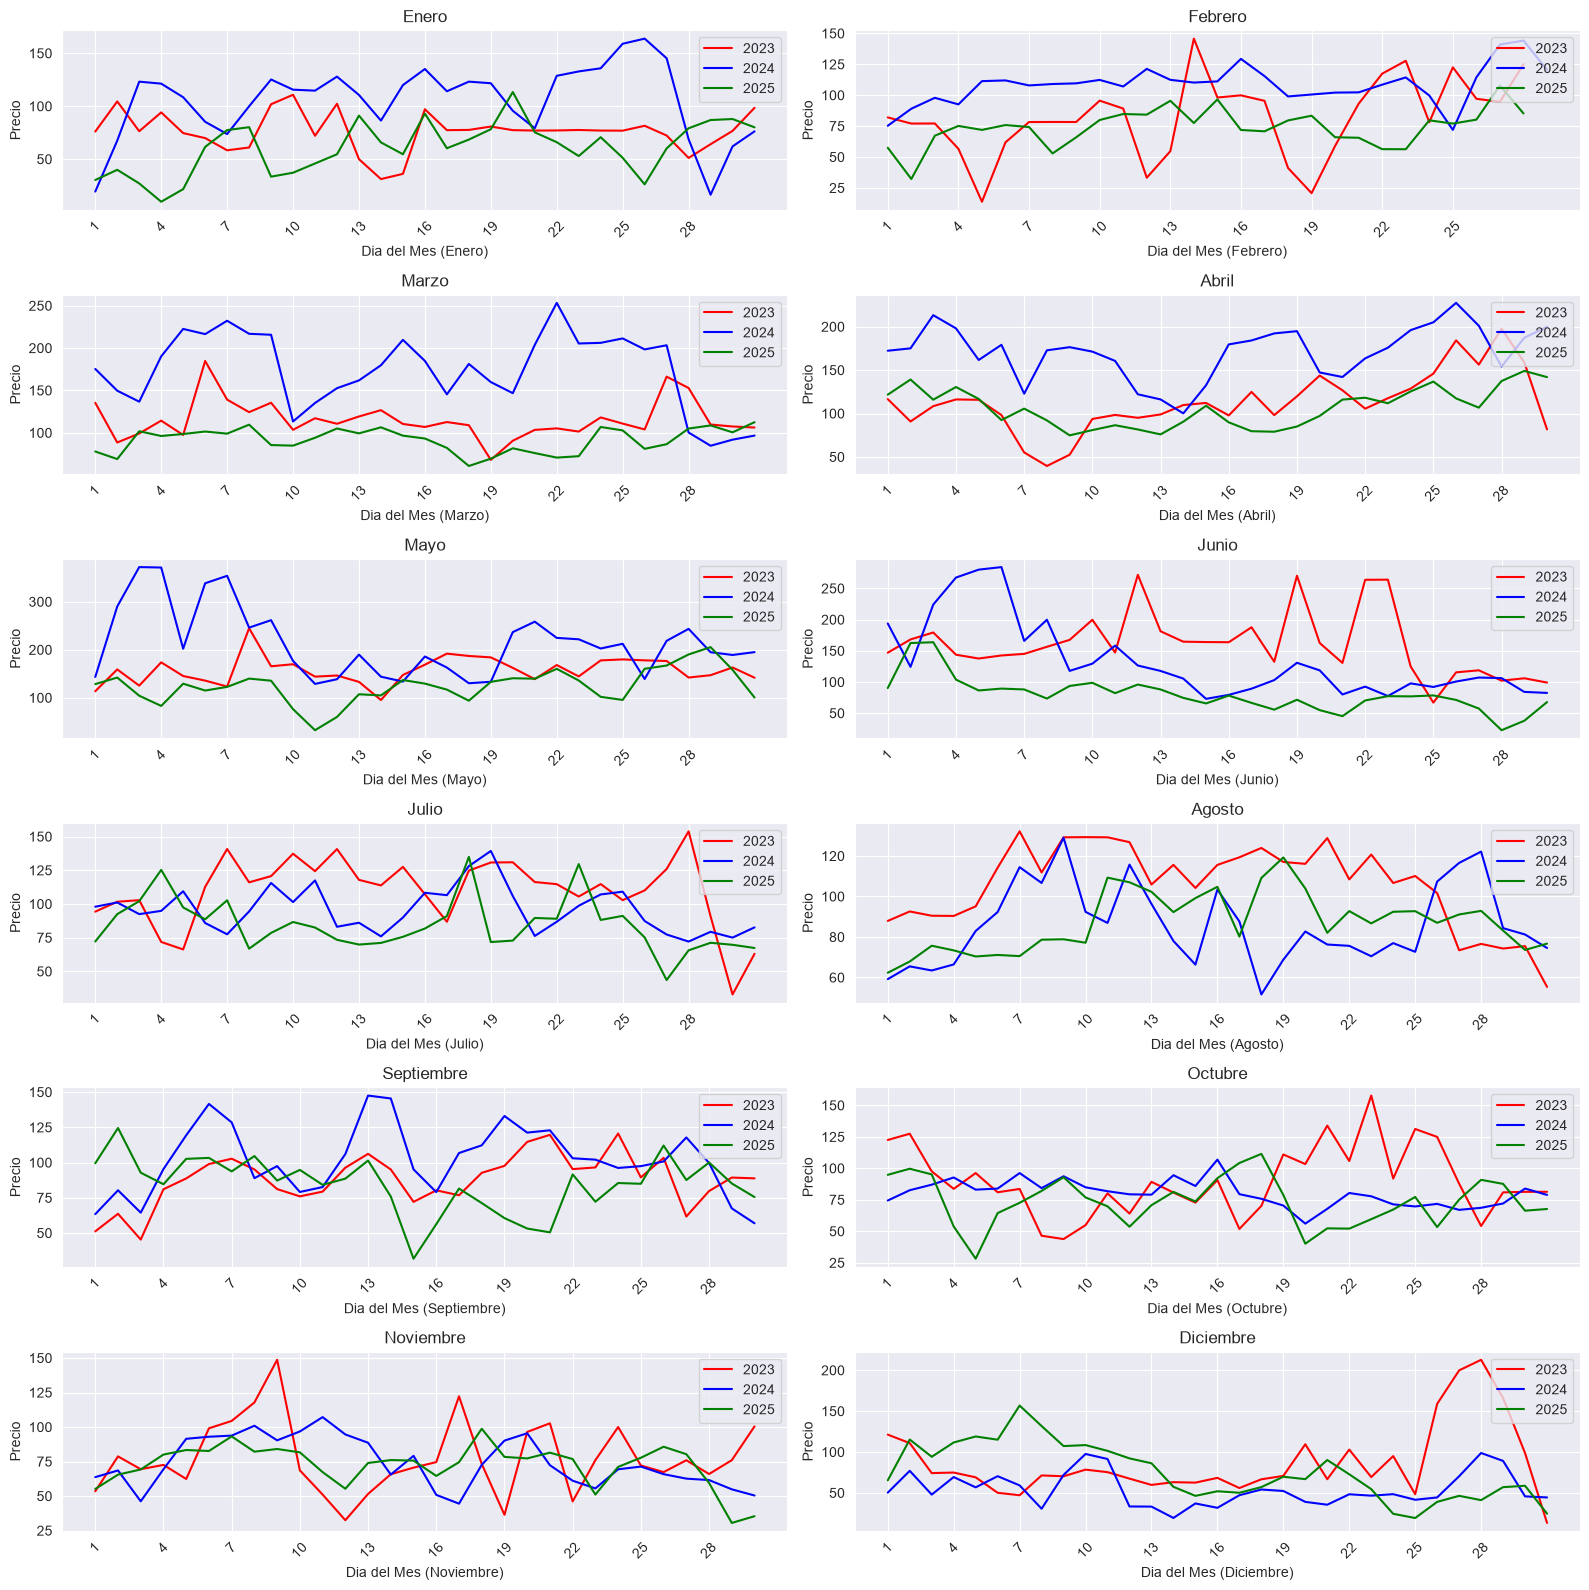

In [17]:
render_monthly_profile(prices, rolling_window=1, use_pct_change=False)

In [18]:
def render_quarterly_profile(data, rolling_window=7, use_pct_change=False):
    quarterly = data.copy().reset_index()
    quarterly['dia_del_trimestre'] = quarterly.groupby(
        [quarterly['dia'].dt.year, quarterly['dia'].dt.quarter]
    )['dia'].rank(method='first').astype(int)
    quarterly['trimestre'] = quarterly['dia'].dt.quarter
    quarterly['year'] = quarterly['dia'].dt.year

    line_style = '-'
    label = 'Precio'

    if use_pct_change:
        quarterly['precio'] = quarterly['precio'].rolling(rolling_window).mean().pct_change()
        line_style = '--'
        label = 'Precio Δ%'
    else:
        quarterly['precio'] = quarterly['precio'].rolling(rolling_window).mean()

    y = quarterly.groupby(['year', 'trimestre', 'dia_del_trimestre'])['precio'].mean().reset_index()
    y['precio'].apply(lambda x: round(x, 2))

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    trimestres = ['Q1 (Ene-Mar)', 'Q2 (Abr-Jun)', 'Q3 (Jul-Sep)', 'Q4 (Oct-Dic)']
    trimestre_orden = [0, 2, 1, 3]
    colors = ['red', 'blue', 'green']

    for trimestre_index in range(4):
        trimestre = trimestre_orden[trimestre_index]

        ax = axes[trimestre_index % 2, trimestre_index // 2]
        ax.set_ylabel(label)
        for year_index in range(0, 3):
            m = y[(y['year'] == year_index + 2023) & (y['trimestre'] == trimestre + 1)]
            sns.lineplot(m, x='dia_del_trimestre', y='precio', ax=ax, linestyle=line_style, color=colors[year_index], label=year_index + 2023)

        ax.set_title(trimestres[trimestre])
        last_day = y[y['trimestre'] == trimestre + 1]['dia_del_trimestre'].max()
        ax.set_xticks(ticks=range(1, last_day, 7))
        ax.tick_params(axis='x', rotation=45)
        ax.set_xlabel(f'Dia del Trimestre ({trimestres[trimestre]})')
        ax.legend(loc='upper right')

    plt.tight_layout()

### Visualización Trimestral (precios absolutos)

A escala trimestral se aprecia que el diferencial entre años es máximo en Q1-Q2 (época seca) y converge en Q3-Q4 (época lluviosa). Esto sugiere un **término de interacción** `year_2024 × is_dry_season` para capturar que el efecto 2024 fue concentrado en los meses de mayor estrés hídrico.

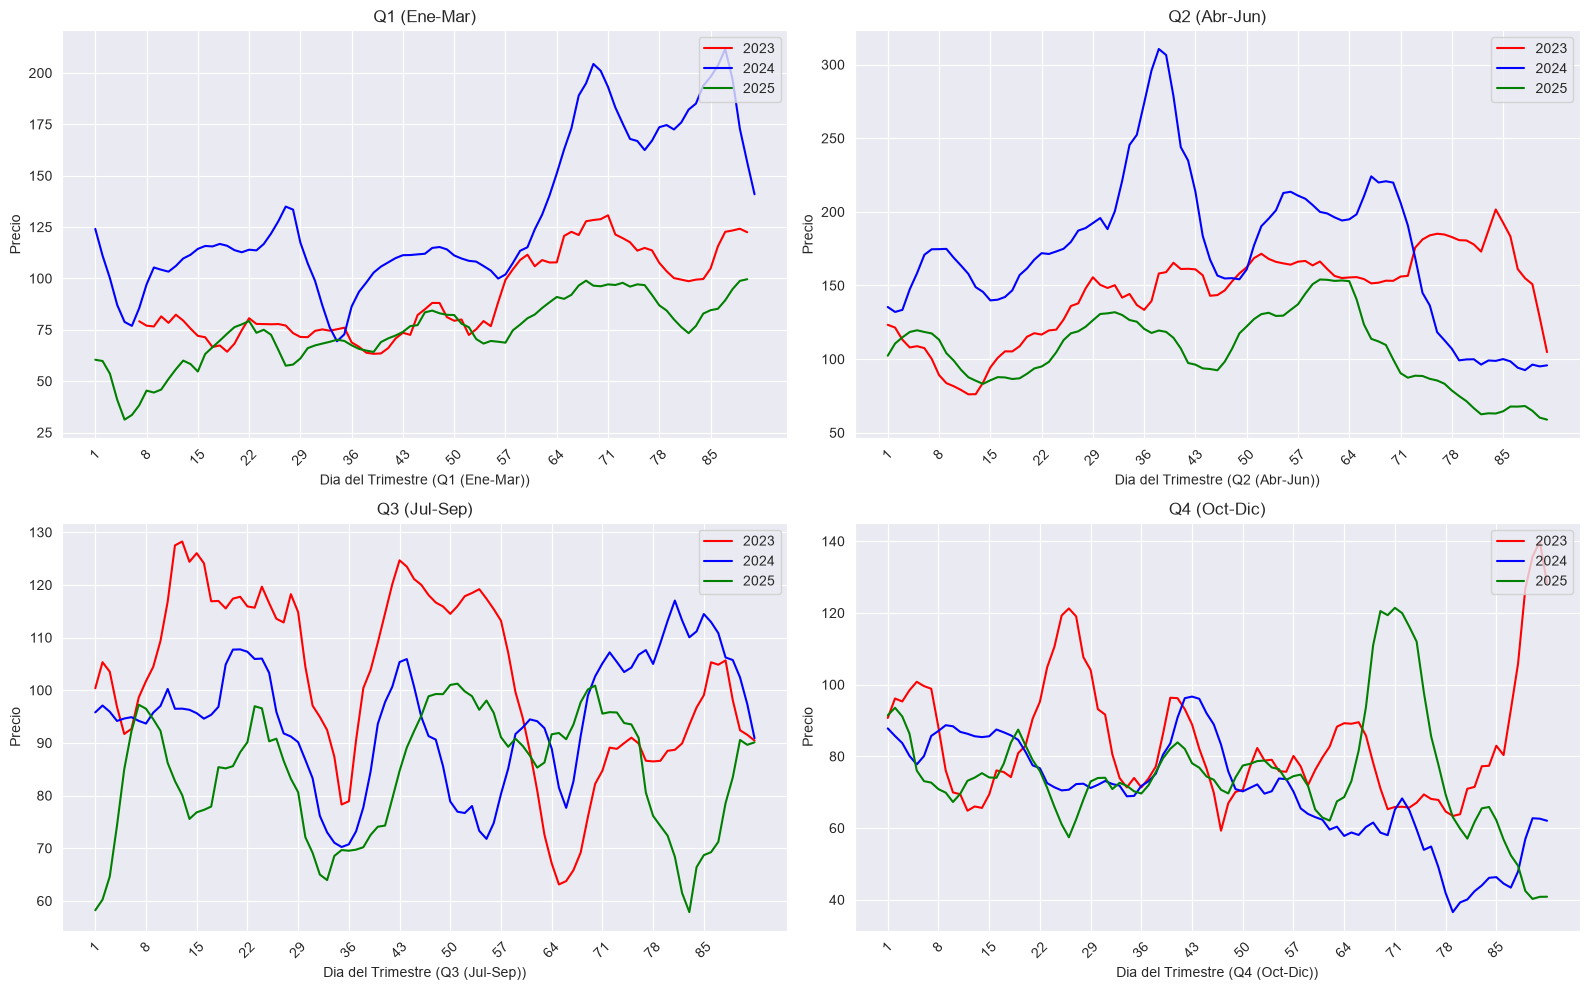

In [19]:
render_quarterly_profile(prices, rolling_window=7, use_pct_change=False)

### Promedios Mensuales Agregados

El promedio mensual histórico muestra el perfil sinusoidal anual: mínimo en diciembre (~75 Q/MWh), pico en mayo (~150 Q/MWh), descenso sostenido en Q3-Q4. Este perfil valida el *phase shift* de -60 días aplicado al encoding sinusoidal.

<Axes: xlabel='mes', ylabel='precio'>

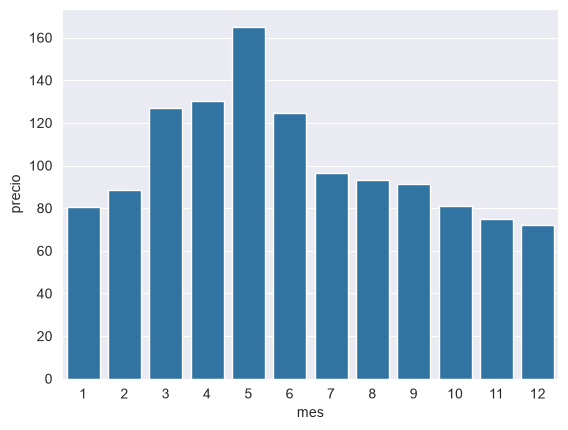

In [20]:
data['mes'] = data['dia'].dt.month
y = data.groupby('mes')['precio'].mean()
sns.barplot(y)

### Histograma de Precios

La distribución de precios es **sesgada a la derecha**: la mayoría de observaciones se concentran entre 77–148 Q/MWh, con cola hasta ~360 Q/MWh correspondiente a picos de 2024. Esta asimetría sugiere explorar una transformación logarítmica del target (`log1p(precio)`) para mejorar el ajuste lineal.

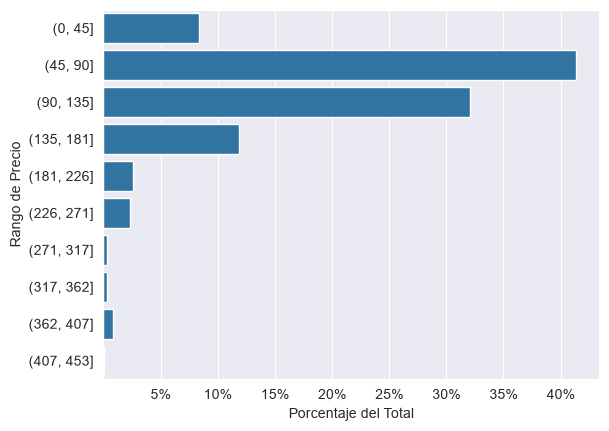

In [21]:
min_val = int(np.floor(data['precio'].min()))
max_val = int(np.ceil(data['precio'].max()))
bins    = np.linspace(min_val, max_val, 11).astype(int)  # 26 edges = 25 bins

y = (
    pd.cut(data['precio'], bins=bins)
    .value_counts()
    .sort_index()
    .reset_index()
)
y['count'] = y['count'] / y['count'].sum() * 100
sns.barplot(y, x='count', y='precio')
plt.xlabel('Porcentaje del Total')
plt.ylabel('Rango de Precio')
plt.xticks(ticks=range(5, 45, 5), labels=list(map(lambda x: f"{x}%", list(range(5, 45, 5)))))
plt.show()

## Selección de Variables

### Proceso de Selección

La selección de variables se realizó mediante un proceso iterativo combinando tres técnicas:

1. **Análisis de correlación R²** entre cada variable candidata y `precio` (a frecuencia diaria)
2. **Análisis de multicolinealidad** entre features para evitar redundancia
3. **Análisis de forma funcional** (FFT, ACF, perfil semanal) para determinar la codificación óptima de cada variable

---

### Variables Descartadas

| Variable | R² vs precio | Razón de descarte |
|---|---|---|
| `oil_price_usd` | 0.05 | Señal débil. Guatemala opera matriz predominantemente hidroeléctrica; el petróleo solo impacta en despacho térmico de emergencia |
| `oil_price_lag_90d`, `oil_price_lag_180d` | 0.05 | R²=0.89–0.92 entre sí y con `oil_price_usd` — multicolinealidad severa sin ganancia predictiva |
| `precipitation_mm` | 0.00 | Sin correlación directa con precio diario |
| `precip_lag_1y` | 0.03 | Correlación débil y R²=0.44 con `dia_anual_cos` — redundante con el encoding estacional |
| `precip_lag_2y` | 0.07 | Señal marginal, alta colinealidad con encoding sinusoidal (R²=0.43–0.55) |
| `mes_del_anno` | 0.08 | R²=0.99 con `dia_anual` — completamente redundante |
| `dia_anual` (raw) | 0.08 | Reemplazado por encoding sin/cos que captura la forma sinusoidal correctamente |
| `hora` (raw) | — | Reemplazado por dummies de hora — la relación es no-lineal y asimétrica |
| `dia_semanal` (raw) | — | Reemplazado por dummies de día — evita asumir linealidad entre días |
| `is_peak_hour` | — | Subsumida por las dummies de hora, que son más granulares |
| `is_dry_season` | — | Capturado por `dia_anual_sin/cos` con mayor precisión |
| `mes` dummies | — | Redundantes dado el encoding sinusoidal — confirmado por análisis Δ% mensual |

---

### Variables Seleccionadas

#### Variables Temporales Cíclicas

| Variable | Tipo | Descripción |
|---|---|---|
| `dia_anual_sin` | continua | sin(2π·(día + 60)/365) — captura el pico estacional anual en mayo-junio |
| `dia_anual_cos` | continua | cos(2π·(día + 60)/365) — complemento ortogonal del ciclo anual |
| `hora_1` ... `hora_23` | 23 dummies | Perfil horario libre — captura la curva asimétrica diaria sin restricción funcional |
| `dia_semanal_1` ... `dia_semanal_6` | 6 dummies | Descuento de fin de semana — lunes como referencia |

El *phase shift* de +60 días en el encoding sinusoidal fue determinado empíricamente: alinea el pico de `dia_anual_sin` con el pico histórico de precios (semana 21–23 del año), mejorando R² de 0.17 a 0.27.

#### Variables Externas

| Variable | R² vs precio | Descripción |
|---|---|---|
| `temperature` | 0.44 | Temperatura media diaria en Cobán, Alta Verapaz (proxy cuenca Chixoy). Variable externa más predictiva — actúa como proxy de disponibilidad hídrica |

#### Variables Inter-anuales

| Variable | Tipo | Descripción |
|---|---|---|
| `year_2024` | dummy | Premio de precio relativo a 2023 — año de El Niño fuerte, inicio de lluvias retrasado |
| `year_2025` | dummy | Descuento de precio relativo a 2023 — año post-Niño con reservorios recuperados |
| `year_2024_x_dry_season` | interacción | Captura que el diferencial de 2024 fue concentrado en Q1-Q2, no uniforme durante el año |

---

### Feature Set Final

```python
FEATURES = [
    # Estacionalidad anual (phase shift -60 días)
    'dia_anual_sin', 'dia_anual_cos',

    # Perfil horario (23 dummies, hora_0 = referencia)
    *[f'hora_{h}' for h in range(1, 24)],

    # Perfil semanal (6 dummies, lunes = referencia)
    *[f'dia_semanal_{d}' for d in range(1, 7)],

    # Variable externa
    'temperature',

    # Nivel inter-anual
    'year_2024', 'year_2025',

    # Interacción año × estación
    'year_2024_x_dry_season',
]
```

**Total: 35 features** — 2 continuas, 33 binarias.

---

### Justificación del Uso de Dummies vs. Encodings Continuos

La regresión lineal solo puede modelar relaciones lineales. Para variables cíclicas como `hora` y `dia_semanal`, un encoding numérico directo asumiría que el precio aumenta o disminuye monótonamente con la hora, lo cual contradice el perfil observado (valle nocturno → pico diurno → valle nocturno). Las dummies permiten que el modelo aprenda un nivel de precio independiente para cada categoría sin ninguna restricción sobre la forma de la relación.

In [22]:
FEATURES = [
    # Variables sinusoidales para capturar la estacionalidad anual
    # `sin` es la que tiene mayor importancia (R2 = 0.26), mientras que `cos`
    # es de menor importancia (R2 = 0.03)
    'dia_anual_sin',
    'dia_anual_cos',
    'dia_anual',

    # One-hot encoding por cada hora para capturar la relación no-lineal del patrón de
    # consumo diario. Omitimos la hora 0.
    *[f'hora_{h}' for h in range(1, 24)],
    'hora',
    'hora_sin',
    'hora_cos',

    # One-hot encoding por cada día de la semana para capturar diferencias entre cada día
    # especialmente las diferencias entre semana (Lunes a Viernes) y fin de semana (Sabado y Domingo)
    # Omitimos el día 0.
    *[f'dia_semanal_{d}' for d in range(1, 7)],

    # One-hot encoding por cada año para capturar diferencias entre los diversos años.
    # Omitimos el año 2023.
    'year_2024', 'year_2025',

    # Temperatura
    'temperature',
    'precip_lag_1y',

    # Precios con lag
    # 'precio_lag_1h',
    # 'precio_lag_24h',
    # 'precio_lag_168h',

    # Precios con z-transform
    # 'precio_z',
    # 'precio_z_lag_1h',
    # 'precio_z_lag_24h',
    # 'precio_z_lag_168h',

    # Precipitación de hace 1 año
    # La data muestra un patrón donde el pico de precipitación del año anterior afecta inversamente al precio actual.
    #    * Pico bajo = precio alto el siguiente año.
    #    * Pico alto = precio bajo el siguiente año.
#    'precip_max_last_year'
]
FEATURES

['dia_anual_sin',
 'dia_anual_cos',
 'dia_anual',
 'hora_1',
 'hora_2',
 'hora_3',
 'hora_4',
 'hora_5',
 'hora_6',
 'hora_7',
 'hora_8',
 'hora_9',
 'hora_10',
 'hora_11',
 'hora_12',
 'hora_13',
 'hora_14',
 'hora_15',
 'hora_16',
 'hora_17',
 'hora_18',
 'hora_19',
 'hora_20',
 'hora_21',
 'hora_22',
 'hora_23',
 'hora',
 'hora_sin',
 'hora_cos',
 'dia_semanal_1',
 'dia_semanal_2',
 'dia_semanal_3',
 'dia_semanal_4',
 'dia_semanal_5',
 'dia_semanal_6',
 'year_2024',
 'year_2025',
 'temperature',
 'precip_lag_1y']

In [23]:
hora_dummies = pd.get_dummies(data['hora'], prefix='hora', drop_first=True).astype(int)
week_dummies = pd.get_dummies(data['dia_semanal'], prefix='dia_semanal', drop_first=True).astype(int)
year_dummies = pd.get_dummies(data['dia'].dt.year, prefix='year', drop_first=False).astype(int)

processed_data = pd.concat([data, hora_dummies, week_dummies, year_dummies], axis=1)

# Eliminar todas las columnas no necesarias
drop_columns = list(set(processed_data.columns.tolist()) - set(FEATURES + ['precio', 'precio_z', 'dia', 'hora', 'year']))
processed_data = processed_data.drop(drop_columns, axis=1)

# Agrupar por dia
# processed_data = processed_data.groupby('dia').agg(
#     precio=('precio', 'mean'),
#     precio_z=('precio_z', 'mean'),
#     # temperature=('temperature', 'first'),
#     # precip_lag_1y=('precip_lag_1y', 'first'),
#     dia_semanal_1=('dia_semanal_1', 'first'),
#     dia_semanal_2=('dia_semanal_2', 'first'),
#     dia_semanal_3=('dia_semanal_3', 'first'),
#     dia_semanal_4=('dia_semanal_4', 'first'),
#     dia_semanal_5=('dia_semanal_5', 'first'),
#     dia_semanal_6=('dia_semanal_6', 'first'),
#     dia_anual_sin=('dia_anual_sin', 'first'),
#     # dia_anual_cos=('dia_anual_cos', 'first'),
#     dia_anual=('dia_anual', 'first'),
#     year=('year', 'first'),
#     year_2024=('year_2024', 'first'),
#     year_2025=('year_2025', 'first'),
# ).reset_index()
processed_data

,dia,hora,precio,dia_anual,year,precio_z,hora_sin,hora_cos,dia_anual_sin,dia_anual_cos,...,hora_22,hora_23,dia_semanal_1,dia_semanal_2,dia_semanal_3,dia_semanal_4,dia_semanal_5,dia_semanal_6,year_2024,year_2025
0,2023-01-01,0,74.2314,1,2023,-0.600525,0.000000,1.000000,-0.849817,0.527078,...,0,0,0,0,0,0,0,1,0,0
1,2023-01-01,1,74.2314,1,2023,-0.600525,0.258819,0.965926,-0.849817,0.527078,...,0,0,0,0,0,0,0,1,0,0
2,2023-01-01,2,59.0752,1,2023,-0.893126,0.500000,0.866025,-0.849817,0.527078,...,0,0,0,0,0,0,0,1,0,0
3,2023-01-01,3,59.0752,1,2023,-0.893126,0.707107,0.707107,-0.849817,0.527078,...,0,0,0,0,0,0,0,1,0,0
4,2023-01-01,4,80.9615,1,2023,-0.470595,0.866025,0.500000,-0.849817,0.527078,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26299,2025-12-31,19,40.7299,365,2025,-1.187435,-0.965926,0.258819,-0.858764,0.512371,...,0,0,0,1,0,0,0,0,0,1
26300,2025-12-31,20,1.9739,365,2025,-2.236535,-0.866025,0.500000,-0.858764,0.512371,...,0,0,0,1,0,0,0,0,0,1
26301,2025-12-31,21,1.6123,365,2025,-2.246323,-0.707107,0.707107,-0.858764,0.512371,...,0,0,0,1,0,0,0,0,0,1
26302,2025-12-31,22,1.0306,365,2025,-2.262070,-0.500000,0.866025,-0.858764,0.512371,...,1,0,0,1,0,0,0,0,0,1


### Finalmente Almacenamos la Data Procesada

In [26]:
processed_data.to_csv('data/ProcessedData-2023-to-2025.csv', index=False)
processed_data.head(500).to_csv('data/ProcessedData-2023-to-2025-head.csv', index=False)